In [ ]:

import pandas as pd

# Load your final cleaned dataset (no rank columns)
df = pd.read_csv("DM1_game_dataset_module.01 (1).csv")

# Quick check
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

✅ Dataset loaded successfully!
Shape: (21925, 42)


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,1.609438,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,1.791759,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,1.791759,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,1.098612,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,1.609438,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [ ]:
import pandas as pd
df = pd.read_csv("DM1_game_dataset_module.01 (1).csv")
print(sorted(df.columns))


['BGGId', 'Cat:Abstract', 'Cat:CGS', 'Cat:Childrens', 'Cat:Family', 'Cat:Party', 'Cat:Strategy', 'Cat:Thematic', 'Cat:War', 'ComAgeRec', 'ComMaxPlaytime', 'ComMinPlaytime', 'ComWeight', 'Description', 'GameWeight', 'GoodPlayers', 'ImagePath', 'IsReimplementation', 'Kickstarted', 'LanguageEase', 'MaxPlayers', 'MfgAgeRec', 'MinPlayers', 'Name', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'NumOwned', 'NumUserRatings', 'NumWant', 'NumWeightVotes', 'NumWish', 'Rank:abstracts', 'Rank:cgs', 'Rank:childrensgames', 'Rank:familygames', 'Rank:partygames', 'Rank:strategygames', 'Rank:thematic', 'Rank:wargames', 'Rating', 'YearPublished']


In [ ]:
df.shape


(21925, 42)

In [ ]:
import pandas as pd

df = pd.read_csv("DM1_game_dataset_module.01 (1).csv")
print([c for c in df.columns if c in ["BestPlayers", "Family", "NumComments"]])


[]


I will use only numerical and structural features (All numeric, None related to popularity, No sparse categorical (dummy), No text or ID, only variables describing gameplay and structure.

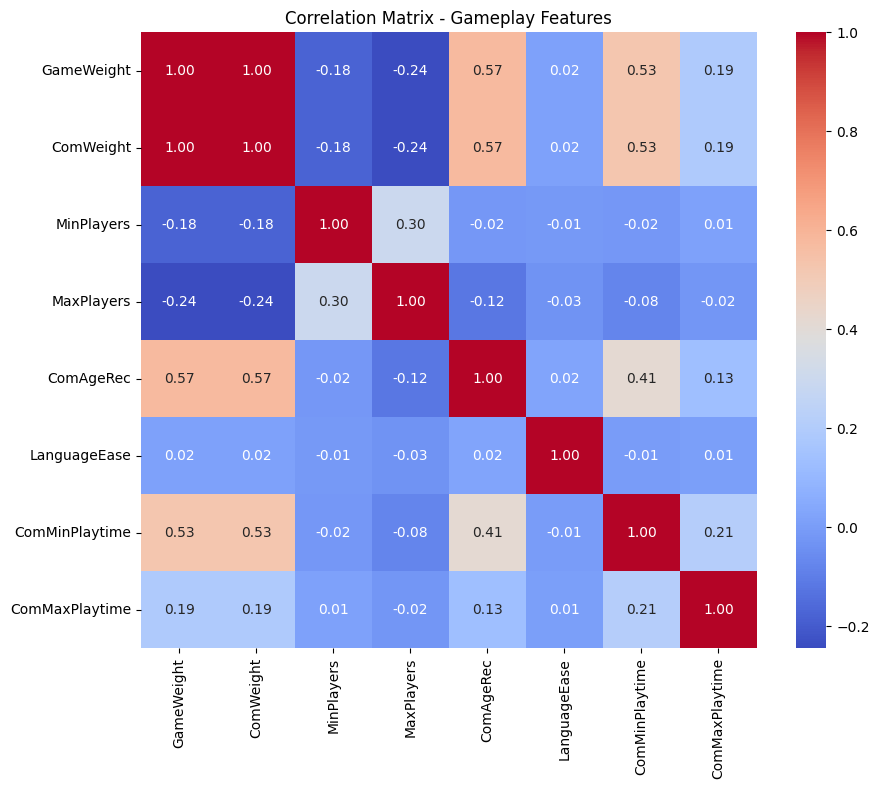

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carico dataset
df = pd.read_csv("DM1_game_dataset_module.01 (1).csv")

# Feature scelte
features_hierarchical = [
    "GameWeight",
    "ComWeight",
    "MinPlayers",
    "MaxPlayers",
    "ComAgeRec",
    "LanguageEase",
    "ComMinPlaytime",
    "ComMaxPlaytime"
]

# Subset del dataset
X = df[features_hierarchical].copy()

# Imputazione NaN (mediana)
X = X.fillna(X.median(numeric_only=True))

# Calcolo matrice di correlazione
corr = X.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Correlation Matrix - Gameplay Features")
plt.show()


Drop GameWeight, highly correlated with ComWeight.

#WITH PCA

Explained variance ratio (PCA 2D): [0.92203133 0.03356794]
Total variance explained: 0.955599273863665


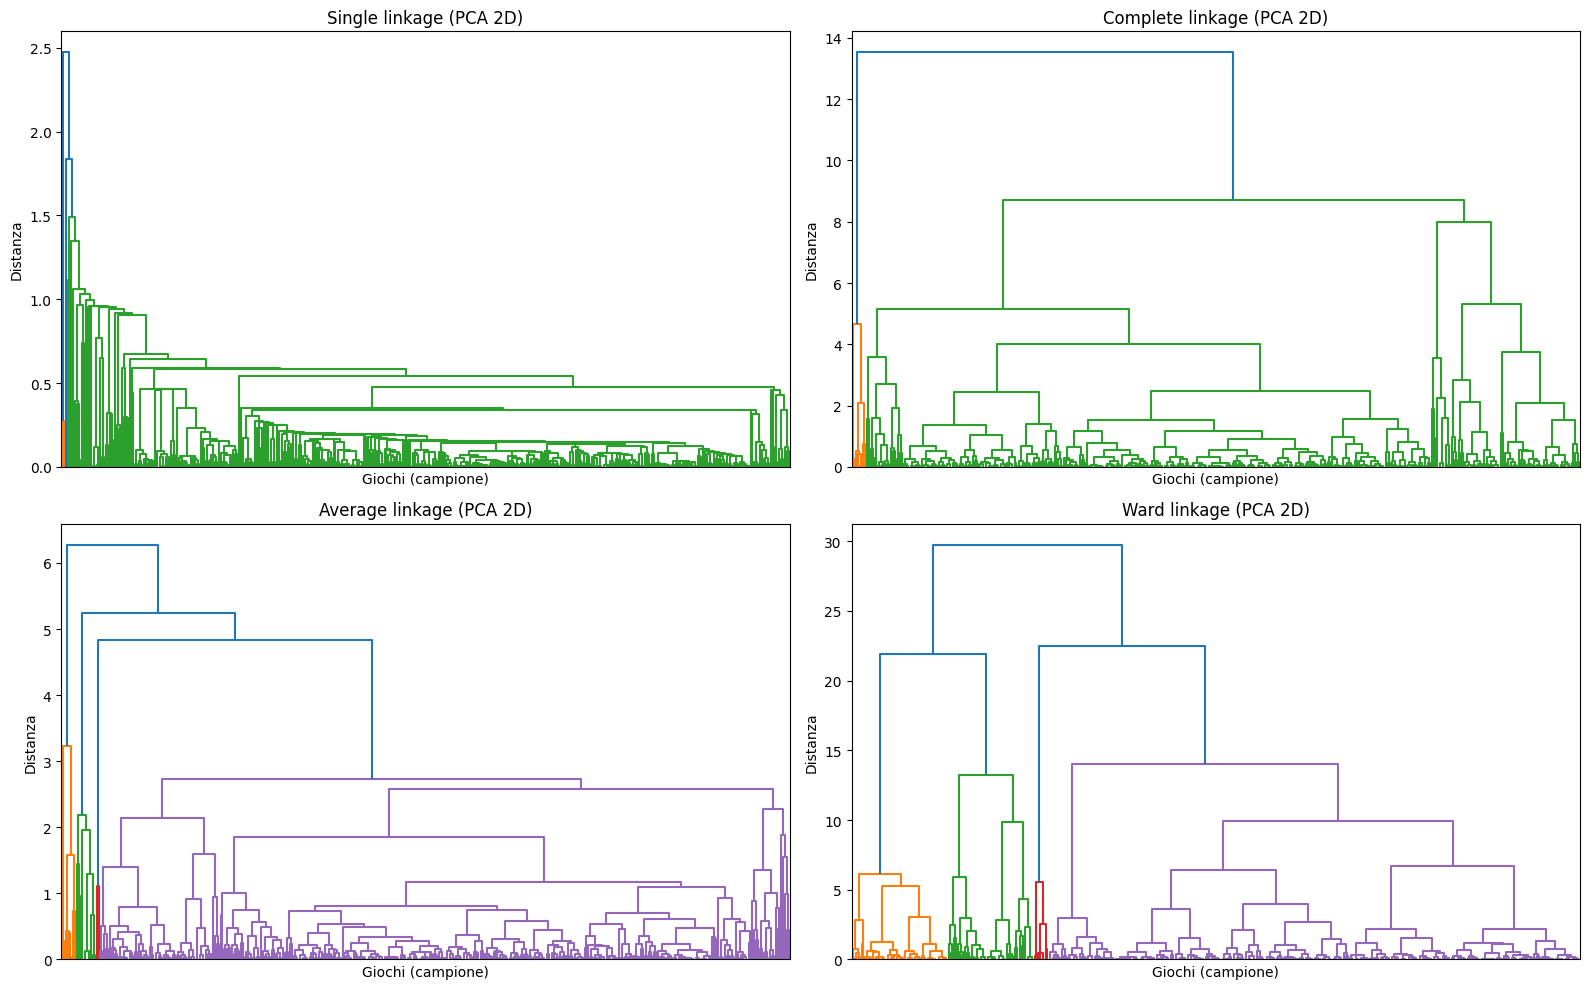

    linkage  n_clusters  silhouette_sample_pca
0    single           1                    NaN
1  complete           2               0.686404
2   average           1                    NaN
3      ward           8               0.363339


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1. LOAD + SCELTA FEATURE


df = pd.read_csv("DM1_game_dataset_module.01 (1).csv")

features_hierarchical = [
    "ComWeight",
    "MinPlayers",
    "MaxPlayers",
    "ComAgeRec",
    "LanguageEase",
    "ComMinPlaytime",
    "ComMaxPlaytime",
]

X = df[features_hierarchical].copy()

# Imputazione NA con mediana
#X = X.fillna(X.median(numeric_only=True))


# 2. SCALING + PCA


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componenti
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio (PCA 2D):", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())


# 3. CAMPIONE PER DENDROGRAMMI

sample_size = 400
sample_df = df.sample(n=sample_size, random_state=42)

X_sample = sample_df[features_hierarchical].copy()
X_sample = X_sample.fillna(X_sample.median(numeric_only=True))
X_sample_scaled = scaler.transform(X_sample)

# PCA anche sul campione
X_sample_pca = pca.transform(X_sample_scaled)


# 4. HIERARCHICAL SU PCA (4 LINKAGE)


methods = ["single", "complete", "average", "ward"]

linkages_pca = {
    m: linkage(X_sample_pca, method=m, metric="euclidean")
    for m in methods
}

# Dendrogrammi (2x2) su PCA
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, m in zip(axes, methods):
    dendrogram(
        linkages_pca[m],
        no_labels=True,
        ax=ax
    )
    ax.set_title(f"{m.capitalize()} linkage (PCA 2D)")
    ax.set_xlabel("Giochi (campione)")
    ax.set_ylabel("Distanza")

plt.tight_layout()
plt.show()


# 5. CUT + SILHOUETTE SU PCA


cut_threshold = 9 # from 4 to 10

results = []

for m in methods:
    Z = linkages_pca[m]
    labels = fcluster(Z, t=cut_threshold, criterion="distance")
    n_clust = len(np.unique(labels))

    if n_clust > 1:
        sil = silhouette_score(X_sample_pca, labels)
    else:
        sil = np.nan

    results.append([m, n_clust, sil])

summary_pca = pd.DataFrame(
    results,
    columns=["linkage", "n_clusters", "silhouette_sample_pca"]
)

print(summary_pca)



In [ ]:
from sklearn.cluster import AgglomerativeClustering

k = 3  # from 2-5, look up

hc_pca = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward",
    metric="euclidean"
)

labels_all_pca = hc_pca.fit_predict(X_pca)
df[f"HC_PCA_Ward_k{k}"] = labels_all_pca

print(df[f"HC_PCA_Ward_k{k}"].value_counts())


HC_PCA_Ward_k3
2    21868
0       56
1        1
Name: count, dtype: int64


#Without PCA (not good)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


# 1. CARICO IL DATASET

df = pd.read_csv("DM1_game_dataset_module.01 (1).csv")


features_hierarchical = [
    "ComWeight",
    "MinPlayers",
    "MaxPlayers",
    "ComAgeRec",
    "LanguageEase",
    "ComMinPlaytime",
    "ComMaxPlaytime"
]

X = df[features_hierarchical].copy()


#X = X.fillna(X.median(numeric_only=True))


# 4. ROBUST SCALER

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# -----------------------------
# 5. CAMPIONO UN SOTTOINSIEME PER I DENDROGRAMMI
# -----------------------------
sample_size = 400  # numero di giochi nel campione per plottare
sample_df = df.sample(n=sample_size, random_state=42)

X_sample = sample_df[features_hierarchical].copy()
X_sample = X_sample.fillna(X_sample.median(numeric_only=True))
X_sample_scaled = scaler.transform(X_sample)


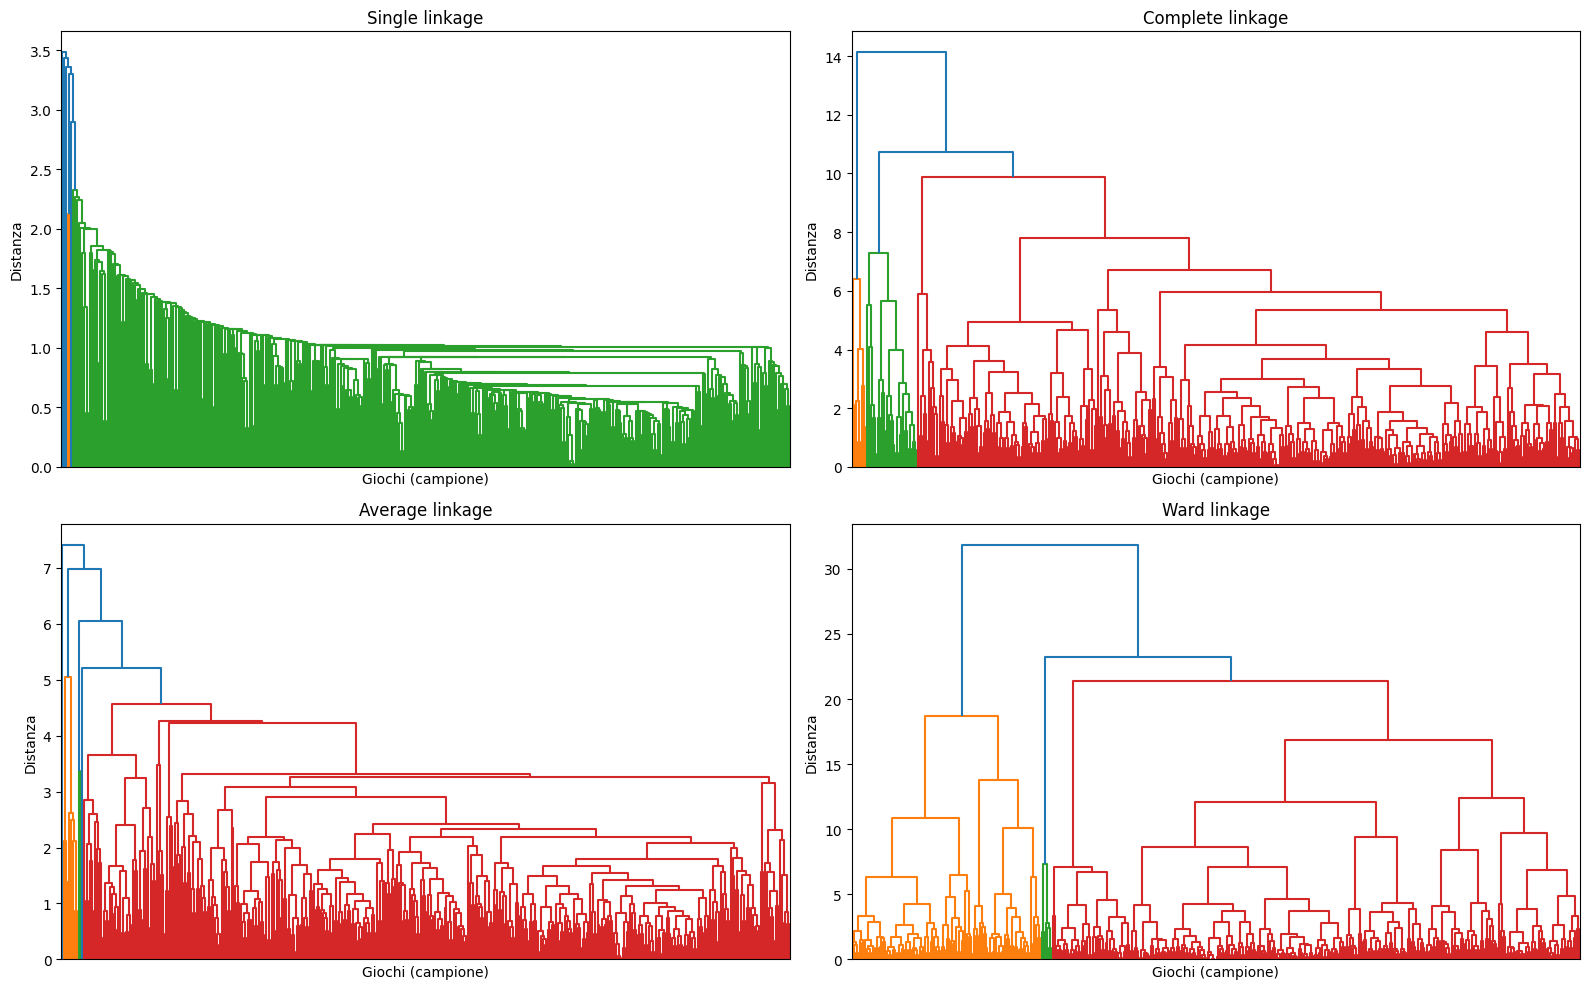

In [ ]:
# -----------------------------
# 6. CALCOLO DELLE LINKAGE (4 METODI)
# -----------------------------
methods = ["single", "complete", "average", "ward"]

linkages = {
    m: linkage(X_sample_scaled, method=m, metric="euclidean")
    for m in methods
}

# -----------------------------
# 7. PLOT DEI 4 DENDROGRAMMI (2x2)
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, m in zip(axes, methods):
    dendrogram(
        linkages[m],
        no_labels=True,   # niente etichette per non esplodere il grafico
        ax=ax
    )
    ax.set_title(f"{m.capitalize()} linkage")
    ax.set_xlabel("Giochi (campione)")
    ax.set_ylabel("Distanza")

plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 8. TAGLIO DEI DENDROGRAMMI + SILHOUETTE
# -----------------------------

cut_threshold = 10  # puoi provare anche 8, 12, 15... per vedere come cambia

results = []

for m in methods:
    Z = linkages[m]

    # cluster tramite soglia di distanza
    labels = fcluster(Z, t=cut_threshold, criterion="distance")
    n_clust = len(np.unique(labels))

    # silhouette calcolata solo se ci sono almeno 2 cluster
    if n_clust > 1:
        sil = silhouette_score(X_sample_scaled, labels)
    else:
        sil = np.nan

    results.append([m, n_clust, sil])

summary = pd.DataFrame(
    results,
    columns=["linkage", "n_clusters", "silhouette_sample"]
)

print(summary)


    linkage  n_clusters  silhouette_sample
0    single           1                NaN
1  complete           3           0.254588
2   average           1                NaN
3      ward          11           0.169524


In [ ]:
X = df[features_hierarchical].copy()
#X = X.fillna(X.median(numeric_only=True))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

Z_complete = linkage(
    X_scaled,
    method="complete",
    metric="euclidean"
)

cut_threshold = 10  # puoi rifinirla dopo
labels = fcluster(Z_complete, t=cut_threshold, criterion="distance")

df["cluster"] = labels


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("Explained variance:", pca.explained_variance_ratio_.sum())


Explained variance: 0.955599273863665


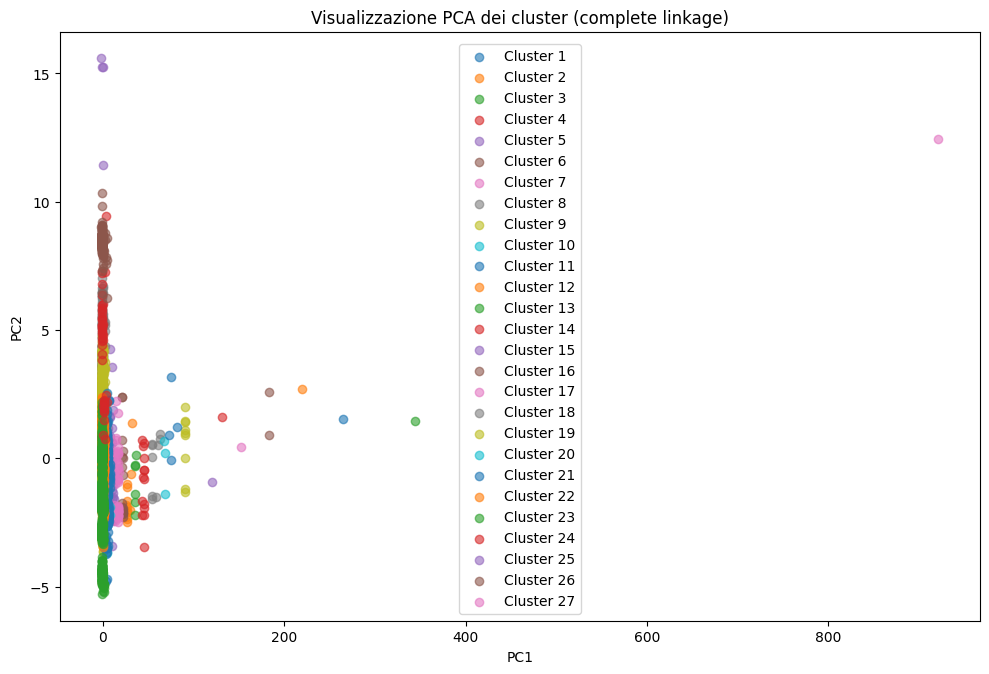

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {c}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualizzazione PCA dei cluster (complete linkage)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
profile = (
    df
    .groupby("cluster")[features_hierarchical]
    .median()
    .round(2)
)

print(profile)


         ComWeight  MinPlayers  MaxPlayers  ComAgeRec  LanguageEase  \
cluster                                                               
1             4.29         2.0        1.61      19.33         23.00   
2             5.04         2.0        1.95      12.00        548.00   
3             4.80         2.0        1.10      14.18          7.40   
4             4.49         2.0        1.95      15.33        323.00   
5             4.01         1.0        1.10      16.00        338.00   
6             4.46         2.0        1.84      13.29         73.47   
7             3.97         1.0        1.61      12.00        374.50   
8             4.48         2.0        1.95      16.00         48.00   
9             4.56         2.0        1.95      15.60        173.00   
10            4.39         1.0        1.95      14.67        363.00   
11            4.51         2.0        2.07      15.50        167.70   
12            4.05         2.0        1.10      15.33         53.00   
13    